In [1]:
from IPython.display import clear_output

%pip install kagglehub catboost lightgbm tqdm -q

clear_output()

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os
from tqdm import tqdm

%matplotlib inline

In [3]:
import kagglehub
path = kagglehub.dataset_download("spscientist/students-performance-in-exams")

100%|██████████| 8.70k/8.70k [00:00<00:00, 10.1MB/s]

Extracting files...


In [4]:
csv_path = os.path.join(path, "StudentsPerformance.csv")

df = pd.read_csv(csv_path)

df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


math Score --> y (Target)

gender, race/ethnicity, parental level of education	, lunch, and test preparation course --> Features

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


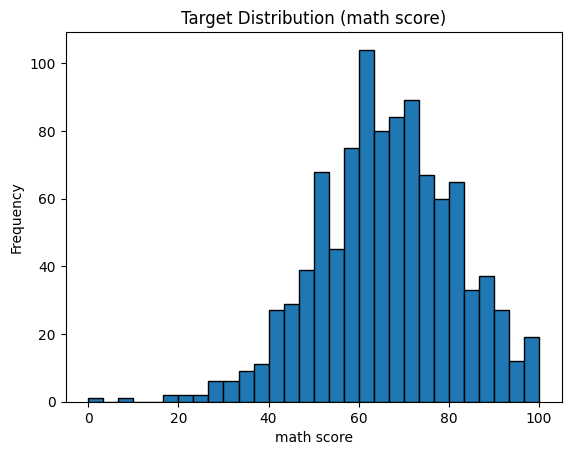

In [6]:
def check_target_distribution(df, target_column):
  df[target_column].hist(bins=30, edgecolor='black')

  plt.title(f"Target Distribution ({target_column})")
  plt.xlabel(target_column)
  plt.ylabel("Frequency")
  plt.grid(False)

  plt.show()

check_target_distribution(df, 'math score')

#Maybe i should do log transform

In [7]:
categorical_cols = df.select_dtypes(include=["object"]).columns

print("Categorical Columns:", list(categorical_cols))

Categorical Columns: ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']


In [8]:
#Encode Categorical columns
from sklearn.preprocessing import LabelEncoder

label_encoders = {}
for col in categorical_cols:
  le = LabelEncoder()
  df[col] = le.fit_transform(df[col])
  label_encoders[col] = le


df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   int64
 1   race/ethnicity               1000 non-null   int64
 2   parental level of education  1000 non-null   int64
 3   lunch                        1000 non-null   int64
 4   test preparation course      1000 non-null   int64
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(8)
memory usage: 62.6 KB


In [9]:
print("Missing Values:")
df.isnull().sum()


Missing Values:


,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.describe()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,0.482000,2.174000,2.486000,0.645000,0.642000,66.08900,69.169000,68.054000
std,0.499926,1.157179,1.829522,0.478753,0.479652,15.16308,14.600192,15.195657
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,17.000000,10.000000
25%,0.000000,1.000000,1.000000,0.000000,0.000000,57.00000,59.000000,57.750000
50%,0.000000,2.000000,2.000000,1.000000,1.000000,66.00000,70.000000,69.000000
75%,1.000000,3.000000,4.000000,1.000000,1.000000,77.00000,79.000000,79.000000
max,1.000000,4.000000,5.000000,1.000000,1.000000,100.00000,100.000000,100.000000


In [12]:
#df['total score']= df['reading score']+ df['math score'] + df['reading score']
#df['average'] = df['total score']/3

In [13]:
from sklearn.preprocessing import MinMaxScaler

features = df.columns.drop("math score")  # DON'T SCALE THE TARGET

scaler = MinMaxScaler() # numbers between 0 and 1
df[features] = scaler.fit_transform(df[features])
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,0.0,0.25,0.2,1.0,1.0,72,0.662651,0.711111
1,0.0,0.50,0.8,1.0,0.0,69,0.879518,0.866667
2,0.0,0.25,0.6,1.0,1.0,90,0.939759,0.922222
3,1.0,0.00,0.0,0.0,1.0,47,0.481928,0.377778
4,1.0,0.50,0.8,1.0,1.0,76,0.734940,0.722222


In [14]:
X = df.drop("math score", axis=1).astype(float)
y = df['math score'].astype(float)

In [15]:
y_log = np.log1p(y) #Log transform because we have left skewed

In [16]:
# Mean Squared Error in NumPy
def mean_squared_error(y, y_hat):
  return (1 / (2 * len(y))) * np.sum((y_hat - y) ** 2)

In [17]:
def gradient_descent(X, y, learning_rate, n_iters=500):
  m, n = X.shape  # m rows, n columns (dimensions)
  theta = np.zeros(n)  # initialize a zeros weight vector with n dimensions
  losses = []

  for _ in tqdm(range(n_iters), desc="Training Linear Regression"):
    y_hat = np.dot(X, theta)
    gradient = np.dot(X.T, (y_hat - y)) / m
    theta -= learning_rate * gradient

    loss = mean_squared_error(y, y_hat)
    losses.append(loss)

  return theta, losses

In [18]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error as sklearn_mse, mean_absolute_error, r2_score

In [19]:
n_splits = 5  # K=5 Folds

# 5-Fold Cross-Validation, shuffled
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

In [20]:
# Storage for linear regression results for each fold
lr_losses = []
lr_mse = []
lr_rmse = []
lr_r2 = []

In [21]:
for fold_idx, (train_index, test_index) in enumerate(kf.split(X)):
  print(f"\nFold {fold_idx + 1}/{n_splits}")

  X_train, X_test = X.iloc[train_index], X.iloc[test_index]
  y_train, y_test = y.iloc[train_index], y.iloc[test_index]

  # Train
  theta, losses = gradient_descent(X_train.values, y_train.values, learning_rate=0.1, n_iters=500)

  # Validate
  y_pred = np.dot(X_test.values, theta)

  # Calculate evaluation metrics
  mse = sklearn_mse(y_test, y_pred)
  rmse = np.sqrt(mse)
  r2 = r2_score(y_test, y_pred)

  # Store results
  lr_losses.append(losses)
  lr_mse.append(mse)
  lr_rmse.append(rmse)
  lr_r2.append(r2)


Fold 1/5


Training Linear Regression: 100%|██████████| 500/500 [00:00<00:00, 11706.06it/s]



Fold 2/5


Training Linear Regression: 100%|██████████| 500/500 [00:00<00:00, 23166.04it/s]



Fold 3/5


Training Linear Regression: 100%|██████████| 500/500 [00:00<00:00, 24380.10it/s]



Fold 4/5


Training Linear Regression: 100%|██████████| 500/500 [00:00<00:00, 28516.39it/s]



Fold 5/5


Training Linear Regression: 100%|██████████| 500/500 [00:00<00:00, 17232.14it/s]


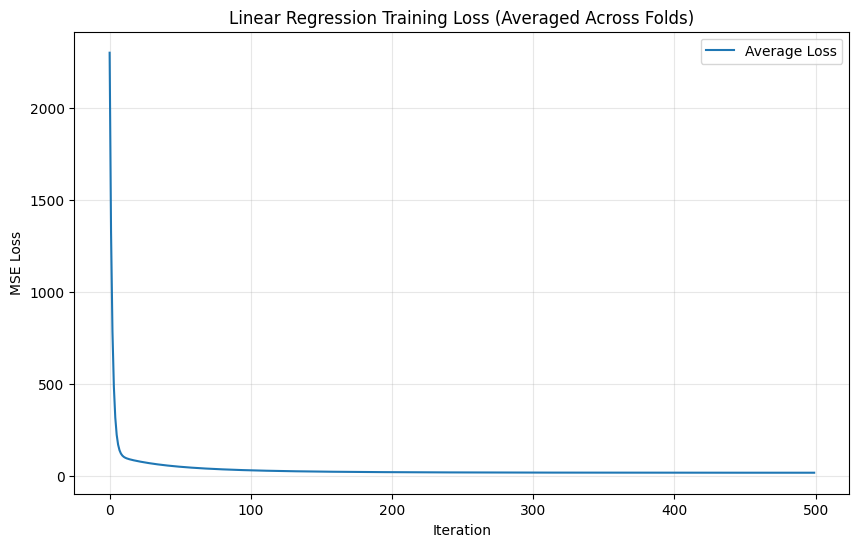

In [22]:
average_losses = np.mean(lr_losses, axis=0)

plt.figure(figsize=(10, 6))
plt.plot(average_losses, label='Average Loss')
plt.xlabel('Iteration')
plt.ylabel('MSE Loss')
plt.title('Linear Regression Training Loss (Averaged Across Folds)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [23]:
print("Linear Regression Results")
print(f"  Average MSE: {np.mean(lr_mse):.4f}")
print(f"  Average RMSE: {np.mean(lr_rmse):.4f}")
print(f"  Average R2:  {np.mean(lr_r2):.4f}")

Linear Regression Results
  Average MSE: 31.7088
  Average RMSE: 5.6261
  Average R2:  0.8610


In [24]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

In [25]:
models = {
  "Ridge Regression": Ridge(alpha=1.0, max_iter=10000),
  "LASSO Regression": Lasso(alpha=1.0,  max_iter=10000),
  "Support Vector Machine": SVR(kernel='rbf'),
  "Decision Tree Regressor": DecisionTreeRegressor(max_depth=10),
  "Random Forest Regressor": RandomForestRegressor(n_estimators=200),
  "LightGBM": LGBMRegressor(verbose=-1),
  "CatBoost": CatBoostRegressor(verbose=0)
}

In [26]:
# Storage for results
all_results = {}

for name in models:
  all_results[name] = {'mse': [], 'rmse': [], 'r2': []}

In [27]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for fold_idx, (train_index, test_index) in enumerate(kf.split(X)):
  print(f"\nFold {fold_idx + 1}/{n_splits}")

  X_train, X_test = X.iloc[train_index], X.iloc[test_index]
  y_train, y_test = y.iloc[train_index], y.iloc[test_index]

  for model_name, model in models.items():
    print(f"Training {model_name}...")

    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Calculate metrics
    mse = sklearn_mse(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    # Store results
    all_results[model_name]["mse"].append(mse)
    all_results[model_name]["rmse"].append(rmse)
    all_results[model_name]["r2"].append(r2)


Fold 1/5
Training Ridge Regression...
Training LASSO Regression...
Training Support Vector Machine...
Training Decision Tree Regressor...
Training Random Forest Regressor...
Training LightGBM...
Training CatBoost...

Fold 2/5
Training Ridge Regression...
Training LASSO Regression...
Training Support Vector Machine...
Training Decision Tree Regressor...
Training Random Forest Regressor...
Training LightGBM...
Training CatBoost...

Fold 3/5
Training Ridge Regression...
Training LASSO Regression...
Training Support Vector Machine...
Training Decision Tree Regressor...
Training Random Forest Regressor...
Training LightGBM...
Training CatBoost...

Fold 4/5
Training Ridge Regression...
Training LASSO Regression...
Training Support Vector Machine...
Training Decision Tree Regressor...
Training Random Forest Regressor...
Training LightGBM...
Training CatBoost...

Fold 5/5
Training Ridge Regression...
Training LASSO Regression...
Training Support Vector Machine...
Training Decision Tree Regres

In [28]:
for model_name in all_results:
  print(f"\n{model_name}:")
  print(f"  MSE:  {np.mean(all_results[model_name]['mse']):.4f}")
  print(f"  RMSE: {np.mean(all_results[model_name]['rmse']):.4f}")
  print(f"  R2:    {np.mean(all_results[model_name]['r2']):.4f}")


Ridge Regression:
  MSE:  31.3902
  RMSE: 5.5974
  R2:    0.8624

LASSO Regression:
  MSE:  84.3324
  RMSE: 9.1802
  R2:    0.6313

Support Vector Machine:
  MSE:  67.9392
  RMSE: 8.2362
  R2:    0.7032

Decision Tree Regressor:
  MSE:  57.6113
  RMSE: 7.5811
  R2:    0.7478

Random Forest Regressor:
  MSE:  37.3763
  RMSE: 6.1114
  R2:    0.8364

LightGBM:
  MSE:  37.2449
  RMSE: 6.1012
  R2:    0.8371

CatBoost:
  MSE:  34.4195
  RMSE: 5.8655
  R2:    0.8494


In [29]:
# Calculate the baseline predictions (mean of the target)
baseline_pred = np.full_like(y, y.mean())

# Evaluate the baseline
baseline_mse = sklearn_mse(y, baseline_pred)
baseline_rmse = np.sqrt(baseline_mse)
baseline_r2 = r2_score(y, baseline_pred)

print(f"Baseline MSE (using mean target): {baseline_mse:.4f}")
print(f"Baseline RMSE (using mean target): {baseline_rmse:.4f}")
print(f"Baseline R2 (using mean target): {baseline_r2:.4f}")

Baseline MSE (using mean target): 229.6891
Baseline RMSE (using mean target): 15.1555
Baseline R2 (using mean target): 0.0000


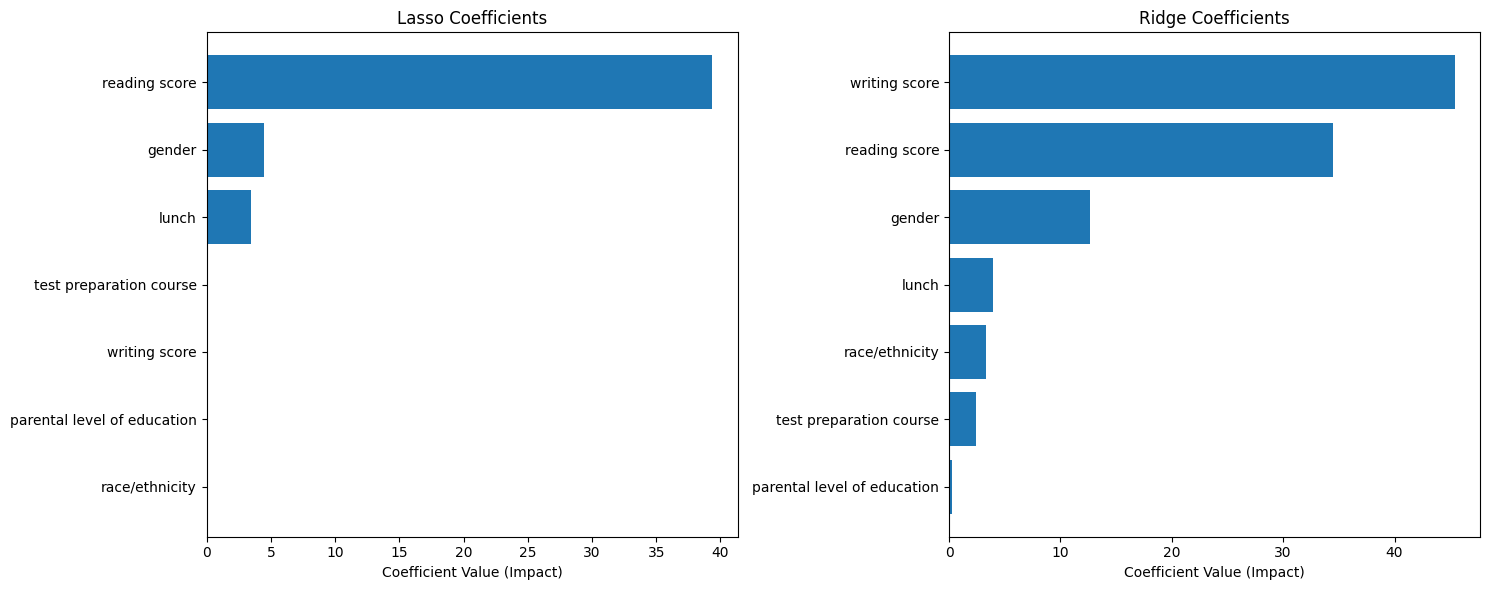

In [30]:
coeffs = {}

coeffs['Lasso'] = models['LASSO Regression'].coef_
coeffs['Ridge'] = models['Ridge Regression'].coef_

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
axes = axes.flatten()
features = X.columns

for i, (model_name, coef) in enumerate(coeffs.items()):
  # Sort features by absolute coefficient value
  absolute_coef = np.abs(coef)
  sorted_idx = np.argsort(absolute_coef)

  ax = axes[i]
  ax.barh(features[sorted_idx], coef[sorted_idx])
  ax.set_title(f"{model_name} Coefficients")
  ax.set_xlabel("Coefficient Value (Impact)")

plt.tight_layout()
plt.show()